In [7]:
import numpy as np

# Initialize:
# - K: number of clusters
# - Data: the input dataset
# - Randomly select K initial centroids

# Repeat:
# - Assign each data point to the nearest centroid (based on Euclidean distance)
# - Calculate the mean of each cluster to update its centroid
# - Check if the centroids have converged (i.e., they no longer change)

# Until:
# - The centroids have converged
# - The maximum number of iterations has been reached

# Output:
# - The final K clusters and their corresponding centroids

class KMeans:
    def __init__(self, k, max_iterations=100):
        self.k = k
        self.max_iterations= max_iterations
        self.centroids = None
    
    def fit(self,X):
        num_samples, num_features = X.shape
        self.centroids = np.random.randn(self.k, num_features)
        
        for _ in range(self.max_iterations):
            # assign each to the nearest centroids
            clusters = self.predict(X)
            new_centroids = np.zeros_like(self.centroids)
            
            for cluster in range(self.k):
                mask = clusters == cluster
                # average by column the data which is part of current cluster
                new_centroid = np.average(X[mask],axis=0)
                new_centroids[cluster] = new_centroid
            
            # check if converged: if the centroids did not change significantly, break
            if np.allclose(self.centroids, new_centroids, atol=1e-7):
                break
            self.centroids = new_centroids


    def predict(self,X):
        cluster_assignments = []
        for x_i in X:
            distances = np.linalg.norm(x_i - self.centroids, axis=1)
            cluster_assignments.append(np.argmin(distances))
        return np.array(cluster_assignments)

In [11]:
x1 = np.random.randn(5,2) + 5
x2 = np.random.randn(5,2) - 5
X = np.concatenate([x1,x2], axis=0)

# Initialize the KMeans object with k=3
kmeans = KMeans(k=2)

# Fit the k-means model to the dataset
kmeans.fit(X)

# Get the cluster assignments for the input dataset
cluster_assignments = kmeans.predict(X)

# Print the cluster assignments
print(cluster_assignments)

# Print the learned centroids
print(kmeans.centroids)

[0 0 0 0 0 1 1 1 1 1]
[[ 5.63299177  4.36784066]
 [-5.17293028 -5.52566878]]


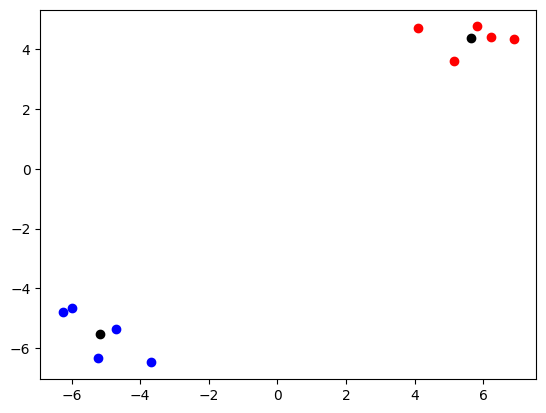

In [12]:
from matplotlib import pyplot as plt
# Plot the data points with different colors based on their cluster assignments
colors = ['r', 'b']
for i in range(kmeans.k):
    plt.scatter(X[np.where(np.array(cluster_assignments) == i)][:,0], 
                X[np.where(np.array(cluster_assignments) == i)][:,1], 
                color=colors[i])

# Plot the centroids as black circles
plt.scatter(kmeans.centroids[:,0], kmeans.centroids[:,1], color='black', marker='o')

# Show the plot
plt.show()